In [6]:
# Scikit-learn - Regression Models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor, SGDRegressor
)

# Scikit-learn - Tree & Ensemble Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor,
    HistGradientBoostingRegressor
)

# Scikit-learn - Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, median_absolute_error,
    explained_variance_score, max_error,
    mean_squared_log_error, root_mean_squared_error,
    mean_poisson_deviance, mean_gamma_deviance,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    log_loss, matthews_corrcoef
)

# Scikit-learn - Model Selection & Preprocessing
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,
    KFold, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, PolynomialFeatures
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

# General
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shortcut import *

In [9]:
dataset = starter()

Great to see you again! Let's get a few questions answered so we can prep your experiment quickly!
Dataset is pulled!


In [10]:
print(dataset)

shape: (1_143, 13)
┌─────────┬──────────┬─────────────┬────────────────┬───┬───────────┬─────────┬─────────┬──────┐
│ fixed   ┆ volatile ┆ citric acid ┆ residual sugar ┆ … ┆ sulphates ┆ alcohol ┆ quality ┆ Id   │
│ acidity ┆ acidity  ┆ ---         ┆ ---            ┆   ┆ ---       ┆ ---     ┆ ---     ┆ ---  │
│ ---     ┆ ---      ┆ f64         ┆ f64            ┆   ┆ f64       ┆ f64     ┆ i64     ┆ i64  │
│ f64     ┆ f64      ┆             ┆                ┆   ┆           ┆         ┆         ┆      │
╞═════════╪══════════╪═════════════╪════════════════╪═══╪═══════════╪═════════╪═════════╪══════╡
│ 7.4     ┆ 0.7      ┆ 0.0         ┆ 1.9            ┆ … ┆ 0.56      ┆ 9.4     ┆ 5       ┆ 0    │
│ 7.8     ┆ 0.88     ┆ 0.0         ┆ 2.6            ┆ … ┆ 0.68      ┆ 9.8     ┆ 5       ┆ 1    │
│ 7.8     ┆ 0.76     ┆ 0.04        ┆ 2.3            ┆ … ┆ 0.65      ┆ 9.8     ┆ 5       ┆ 2    │
│ 11.2    ┆ 0.28     ┆ 0.56        ┆ 1.9            ┆ … ┆ 0.58      ┆ 9.8     ┆ 6       ┆ 3    │
│ 7.4     ┆

In [11]:
# convert polars dataset to pandas then to numpy arrays and split
df = dataset.to_pandas()
X = df.drop(columns=['quality']).to_numpy()
y = df['quality'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


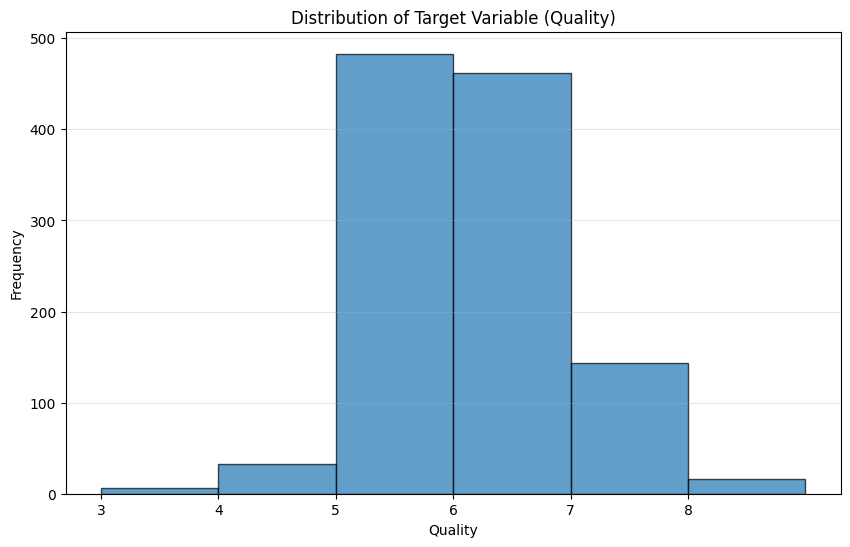

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(y, bins=range(int(y.min()), int(y.max()) + 2), edgecolor='black', alpha=0.7)
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable (Quality)')
plt.xticks(range(int(y.min()), int(y.max()) + 1))
plt.grid(axis='y', alpha=0.3)
plt.show()